In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.linear_model as lm


In [4]:
df = pd.read_csv('house_sample.csv')

In [10]:
#Using Bruteforce Cost Function to find the best w and b
def cost_function(X,y,w,b):
    m = len(X)
    cost = 0
    for i in range(m):
        cost += (y[i] - (np.dot(X[i],w) + b))**2
    return cost/m

In [8]:
X = df.iloc[:,:-1].to_numpy()
y = df.iloc[:,-1].to_numpy()

In [32]:
#Fit a simple linear regression model
model = lm.LinearRegression()
model.fit(X, y)
best_w = model.coef_
best_b = model.intercept_
lowest_cost = cost_function(X, y, best_w, best_b)
print("Linear Regression")
print("Best w:", best_w)
print("Best b:", best_b)
print("Cost:", lowest_cost)
print("Cost: ",cost_function(X,y,best_w,best_b))

Linear Regression
Best w: [  119.83455521  6582.65708656 10667.90462089  -584.38840414
  5128.26559759 -1565.27443431]
Best b: 56644.7055634734
Cost: 163989032.48042953
Cost:  163989032.48042953


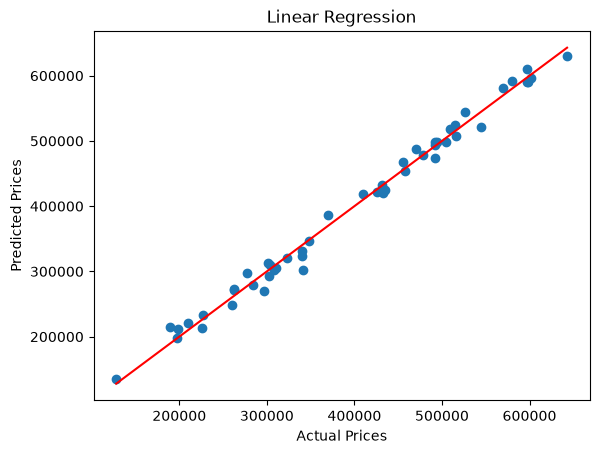

In [20]:
#plot predictions from the trained model
predictions = model.predict(X)
plt.scatter(y, predictions)
plt.plot([min(y), max(y)], [min(y), max(y)], color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression")
plt.show()

In [23]:
new_house = np.array([1800,3,2,11,1,9])
predicted_price = model.predict(new_house.reshape(1, -1))
print(predicted_price)

[298043.20867721]


In [ ]:
def gradient_descent(X,y,alpha,iterations):
    m = len(X)
    w = np.zeros(X.shape[1])
    b = 0
    for i in range(iterations):
        predictions = np.dot(X,w) + b
        errors = predictions - y
        dw = np.dot(X.T,errors)/m
        db = np.mean(errors)
        w = w - alpha * dw
        b = b - alpha * db
    return w,b


In [38]:
alpha = 0.001
iterations = 10000
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std
best_w, best_b = gradient_descent(X_scaled, y, alpha, iterations)
print("Best_W : ",best_w)
print("Best_b : ",best_b)
print("Cost : ",cost_function(X_scaled, y, best_w, best_b))

Best_W :  [131354.29801519   9007.09072618  12492.61672102  -8001.34333592
   6042.40621181 -13221.16593586]
Best_b :  397558.0401617999
Cost :  163993099.87289155


In [39]:
new_house = np.array([1800,3,2,11,1,9])
new_house_scaled = (new_house - X_mean) / X_std
predicted_price = np.dot(new_house_scaled, best_w) + best_b
print("Predicted Price : ", predicted_price)

Predicted Price :  297968.97685017803
